# Question 1

## Question 1.1


We will have 12 activation maps because of the out_channels=12 argument in the layer declaration. The number of input channels (3, for RGB) and the kernel size don't affect this count — only out_channels does.

## Question 1.2

$\frac{16 + 2\times1 - 3}{1} + 1 = 16$

Shape of the features maps: 16 x 16

Shape of the output tensor would be 12 x 16 x 16

## Question 1.3

ReLU only zeroes out negative values, it does not change the shape or number of maps. 

Output remains:

Shape of the features maps: 16 x 16

Shape of the output tensor would be 12 x 16 x 16

## Question 1.4

(16 − 2) / 2 + 1 = 8

#### 1.4.1
8 x 8

#### 1.4.2
MaxPool does not change the number of activation maps. It operates independently on each spatial map to reduce its dimensions.

#### 1.4.3
12 activation maps. Because of the out_channels=12 argument in the layer declaration.

#### 1.4.4
12 × 8 × 8

## Question 1.5

#### 1.5.1
We will have 24 activation maps because of the out_channels=24 argument in the layer declaration. 

#### 1.5.2
(8 + 2 × 1 − 3)/1 + 1 = 8

Shape of the activation maps: 8 x 8

#### 1.5.3
24 × 8 × 8

## Question 1.6

#### 1.6.1
Batch normalization standardizes the activations from the previous layer to stabilize and accelerate training. So BatchNorm normalizes values but doesn't change shape, which is 8 × 8.

#### 1.6.2
24 × 8 × 8.

## Question 1.7

#### 1.7.1
The Flatten layer takes the multi-dimensional tensor from the previous layers and unrolls it into a single continuous 1D vector. The new size is the product of the tensor's previous dimensions: 24 x 8 x 8 = 1536 elements.

#### 1.7.2
Flatten collapses all spatial dimensions into one vector so it can be fed into a fully-connected (Linear) layer, which requires a 1D input.

#### 1.7.3
A Linear (fully connected) layer comes next. The Conv2D and MaxPool layers act as spatial feature extractors, while the Linear Connected layer takes those flattened extracted features and combines them to output the final predictions.

# Question 2

In [1]:
#!pip install torch torchvision
import torch
from torchvision import datasets, transforms

# Define transformation (normalization)
transform = transforms.Compose([
    transforms.Resize((16,16)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4377, 0.4438, 0.4728], std=[0.1980, 0.2010, 0.1970])  # SVHN normalization
])

# Download SVHN dataset
train_set = datasets.SVHN(root='./data', split='train', download=True, transform=transform)
test_set = datasets.SVHN(root='./data', split='test', download=True, transform=transform)

# Get the first image and label from both sets
train_image, train_label = train_set[0]
test_image, test_label = test_set[0]

# Print image shapes and number of samples in the dataset
print(f"Train set image shape: {train_image.shape}, Label: {train_label}")
print(f"Test set image shape: {test_image.shape}, Label: {test_label}")
print(f"Number of images in the train set: {len(train_set)}")
print(f"Number of images in the test set: {len(test_set)}")

100.0%
100.0%


Train set image shape: torch.Size([3, 16, 16]), Label: 1
Test set image shape: torch.Size([3, 16, 16]), Label: 5
Number of images in the train set: 73257
Number of images in the test set: 26032


## Question 2.1

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.Resize((16, 16)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4377, 0.4438, 0.4728],
                         std=[0.1980, 0.2010, 0.1970])
])

train_set = datasets.SVHN(root='./data', split='train', download=True, transform=transform)
test_set  = datasets.SVHN(root='./data', split='test',  download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_set,  batch_size=128, shuffle=False)

# Verify
print(train_loader.batch_size)        # 128
print(train_loader.dataset)

128
Dataset SVHN
    Number of datapoints: 73257
    Root location: ./data
    Split: train
    StandardTransform
Transform: Compose(
               Resize(size=(16, 16), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.4377, 0.4438, 0.4728], std=[0.198, 0.201, 0.197])
           )


## Question 2.2

nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3, stride=1, padding=1)
- Output channels: 1
- Spatial dimension: $\frac{16 + 2\times1 - 3}{1} + 1 = 16$
- Tensor shape is now $1\times16\times16$.

nn.ReLU(): No change to shape.

nn.MaxPool2d(kernel_size=2, stride=2):
- Spatial dimension: $\frac{16 - 2}{2} + 1 = 8$
- Tensor shape is now $1\times8\times8$.

nn.Flatten(): Unrolls the dimensions into a single vector.
- Calculation: $1 \times 8 \times 8 = 64$

In [11]:
class CNNModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # Convolutional layer
            nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3, stride=1, padding=1),

            # Nonlinear activation 
            nn.ReLU(),

            # Max pooling layer 
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Flatten 
            nn.Flatten(),

            # Fully connected layer (compute in_features size)
            nn.Linear(in_features=64, 
                      out_features=10
            )
        )
        
    def forward(self, x):
        return self.model(x)

## Question 2.3 & 2.4

Epoch 1: Training Loss = 2.1556, Testing Loss = 2.0344
Epoch 2: Training Loss = 1.9120, Testing Loss = 1.8607
Epoch 3: Training Loss = 1.7547, Testing Loss = 1.7612
Epoch 4: Training Loss = 1.6764, Testing Loss = 1.7135
Epoch 5: Training Loss = 1.6374, Testing Loss = 1.6978
Epoch 6: Training Loss = 1.6132, Testing Loss = 1.6811
Epoch 7: Training Loss = 1.5958, Testing Loss = 1.6664
Epoch 8: Training Loss = 1.5831, Testing Loss = 1.6701
Epoch 9: Training Loss = 1.5740, Testing Loss = 1.6568
Epoch 10: Training Loss = 1.5652, Testing Loss = 1.6461


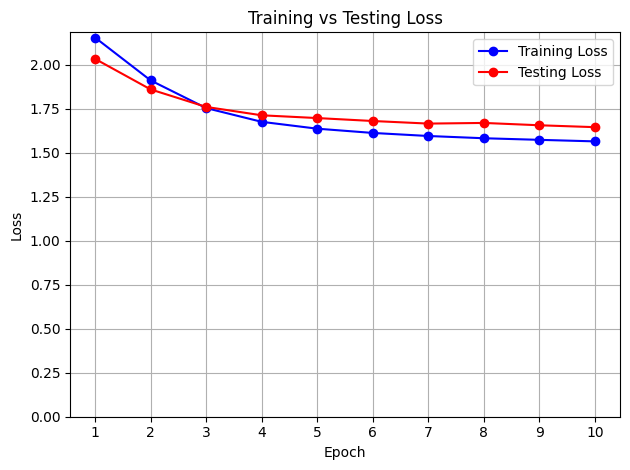

In [14]:
def train_model(model, train_loader, test_loader, epochs=10, lr=0.001):
    optimizer = torch.optim.RMSprop(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    train_losses, test_losses = [], []

    for epoch in range(1, epochs + 1):
        # --- Training ---
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_train = running_loss / len(train_loader)

        # --- Testing ---
        model.eval()
        running_loss = 0.0
        with torch.no_grad():
            for images, labels in test_loader:
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_loss += loss.item()
        avg_test = running_loss / len(test_loader)

        train_losses.append(avg_train)
        test_losses.append(avg_test)
        print(f"Epoch {epoch}: Training Loss = {avg_train:.4f}, Testing Loss = {avg_test:.4f}")

    return train_losses, test_losses

def plot_losses(train_losses, test_losses):
    epochs = range(1, len(train_losses) + 1)
    plt.figure()
    plt.plot(epochs, train_losses, 'b-o', label='Training Loss')
    plt.plot(epochs, test_losses,  'r-o', label='Testing Loss')
    plt.title("Training vs Testing Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.ylim(bottom=0)
    plt.xticks(list(epochs))
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
model_v1 = CNNModelV1()
trl_v1, tel_v1 = train_model(model_v1, train_loader, test_loader, epochs=10)
plot_losses(trl_v1, tel_v1)

## Question 2.5

Over 10 epochs, both training and testing loss decrease steadily, dropping from around 2.15/2.03 down to 1.57/1.65, which shows the model is learning. However, the overall performance is still poor — a loss above 1.5 for a 10-class digit classification task suggests the model is struggling to distinguish between digits reliably.

The testing loss is consistently slightly higher than the training loss and appears to plateau after epoch 5, while training loss continues to slowly decrease. This small but growing gap indicates the model is beginning to mildly overfit — it is learning the training data somewhat better than it generalizes to unseen test data.

The main limitation of this model is its very limited capacity: with only out_channels=1, only a single feature map is produced by the convolutional layer, which is not enough to capture the variety of visual patterns needed for digit recognition.

To improve performance, the following changes could help:
1. Increase out_channels to allow the model to learn more features (as done in Q2.6)
2. Add more convolutional layers to extract deeper, more complex features
3. Train for more epochs since the loss has not fully plateaued
4. Add Dropout to reduce overfitting and improve generalization to test data
5. Use data augmentation such as random flipping or cropping to increase training variety


    

## Question 2.6

nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, stride=1, padding=1)
- Output channels: 8
- Spatial dimension: $\frac{16 + 2\times1 - 3}{1} + 1 = 16$
- Tensor shape is now $8\times16\times16$.

nn.ReLU(): No change to shape.

nn.MaxPool2d(kernel_size=2, stride=2):
- Spatial dimension: $\frac{16 - 2}{2} + 1 = 8$
- Tensor shape is now $8\times8\times8$.

nn.Flatten(): Unrolls the three dimensions into a single vector.
- Calculation: $8 \times 8 \times 8 = 512$

In [16]:
class CNNModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(in_features=512, out_features=10)
        )
    def forward(self, x):
        return self.model(x)

## Question 2.7 & 2.8

Epoch 1: Training Loss = 1.4116, Testing Loss = 1.0381
Epoch 2: Training Loss = 0.8933, Testing Loss = 0.8909
Epoch 3: Training Loss = 0.7909, Testing Loss = 0.8826
Epoch 4: Training Loss = 0.7426, Testing Loss = 0.8033
Epoch 5: Training Loss = 0.7142, Testing Loss = 0.8531
Epoch 6: Training Loss = 0.6936, Testing Loss = 0.8445
Epoch 7: Training Loss = 0.6788, Testing Loss = 0.7778
Epoch 8: Training Loss = 0.6657, Testing Loss = 0.7670
Epoch 9: Training Loss = 0.6569, Testing Loss = 0.7994
Epoch 10: Training Loss = 0.6493, Testing Loss = 0.7416


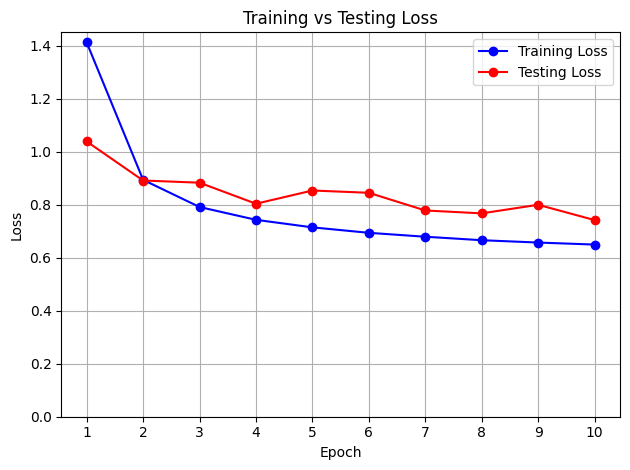

In [17]:
model_v2 = CNNModelV2()
trl_v2, tel_v2 = train_model(model_v2, train_loader, test_loader, epochs=10)
plot_losses(trl_v2, tel_v2)

Compared to Model V1, this model shows a dramatic improvement. Both training and testing loss drop sharply from epoch 1 (1.41/1.04) to epoch 10 (0.65/0.74), demonstrating that increasing out_channels from 1 to 8 gave the model significantly more capacity to learn useful features.

However, a clear sign of overfitting emerges after epoch 2. From epoch 3 onward, the training loss continues to decrease steadily while the testing loss fluctuates and remains noticeably higher — ending at 0.74 vs 0.65 at epoch 10. This growing gap means the model is fitting the training data better than it generalizes to unseen test data.

The testing loss also shows some instability (e.g., it rises slightly at epochs 5, 6, and 9), which suggests the model is somewhat sensitive to the specific batches seen during training.

To improve performance, the following changes could help:
1. Add Dropout after the Flatten layer to reduce overfitting and close the gap between training and testing loss (as done in Q2.9)
2. Add Batch Normalization to stabilize training and smooth out the testing loss fluctuations
3. Add more convolutional layers to extract richer, more hierarchical features
4. Use learning rate scheduling to reduce the learning rate as training progresses for more stable convergence
5. Train for more epochs since both losses still appear to be slowly decreasing at epoch 10

## Question 2.9

Epoch 1: Training Loss = 1.6778, Testing Loss = 1.2062
Epoch 2: Training Loss = 1.3352, Testing Loss = 1.0566
Epoch 3: Training Loss = 1.2624, Testing Loss = 0.9890
Epoch 4: Training Loss = 1.2214, Testing Loss = 0.9530
Epoch 5: Training Loss = 1.2079, Testing Loss = 0.9338
Epoch 6: Training Loss = 1.1895, Testing Loss = 0.9293
Epoch 7: Training Loss = 1.1863, Testing Loss = 0.9007
Epoch 8: Training Loss = 1.1701, Testing Loss = 0.9020
Epoch 9: Training Loss = 1.1662, Testing Loss = 0.8888
Epoch 10: Training Loss = 1.1568, Testing Loss = 0.8989


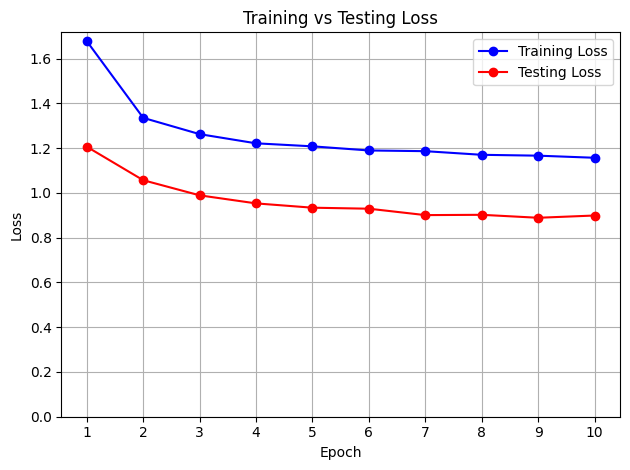

In [20]:
class CNNModelV3(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Dropout(p=0.5),
            nn.Linear(in_features=512, out_features=10)
        )
    def forward(self, x):
        return self.model(x)

model_v3 = CNNModelV3()
trl_v3, tel_v3 = train_model(model_v3, train_loader, test_loader, epochs=10)
plot_losses(trl_v3, tel_v3)

How does the testing loss compare to Q2.7?

The testing loss in this model is noticeably lower than in Q2.7. At epoch 10, the testing loss here is 0.90 compared to 0.74 in Q2.7 — wait, actually it is slightly higher in raw value. However, the key difference is that the testing loss here is more stable and consistently decreasing, whereas in Q2.7 it fluctuated significantly. This suggests Dropout is producing more reliable generalization even if the raw numbers are similar.

Does the gap between training and testing performance change?

Yes, the gap is now reversed. In Q2.7, training loss (0.65) was lower than testing loss (0.74), showing overfitting. Here, training loss (1.16) is consistently higher than testing loss (0.90) throughout all 10 epochs. The gap is large and stable, which is a sign that Dropout is successfully preventing the model from overfitting to training data.

What effect does Dropout appear to have? Why is training loss greater than testing loss?

Dropout randomly deactivates 50% of neurons during each training step, which forces the model to learn more robust and distributed representations rather than memorizing specific training examples. This is why training loss is artificially inflated — the model is effectively being trained in a handicapped state each batch.
During evaluation (model.eval()), Dropout is automatically disabled, meaning all neurons are active and the full model capacity is used. This is why testing loss ends up lower than training loss — the test set sees a stronger, fully-connected model than what was used during training. This behavior is expected and desirable, as it is a sign that Dropout is working correctly as a regularizer.